In [1]:
##########################################################################################################
#   For the task of segmentation we will be using only malignant and benign classes as the mask for      #
#   normal ultrasound will be zero always (probably!!)                                                   #
#                                                                                                        #
#   Model Used: U-Net                                                                                    #
##########################################################################################################

## Dependencies

In [2]:
## Making essential imports
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split

## Performance coefficients

In [3]:
def dice_coef(y_true, y_pred, smooth=1):
    """
    Calculate Dice coefficient
    """
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """
    Calculate Dice loss
    """
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    """
    Combined loss function of BCE and Dice
    """
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice

def iou_coef(y_true, y_pred, smooth=1):
    """
    Calculate IoU coefficient
    """
    intersection = tf.keras.backend.sum(tf.keras.backend.abs(y_true * y_pred), axis=[1,2])
    union = tf.keras.backend.sum(y_true, axis=[1,2]) + tf.keras.backend.sum(y_pred, axis=[1,2]) - intersection
    iou = tf.keras.backend.mean((intersection + smooth) / (union + smooth))
    return iou

def iou_loss(y_true, y_pred):
    """
    Calculate IoU loss
    """
    return 1 - iou_coef(y_true, y_pred)

## Data Loader

In [4]:
# defining a frame for image and mask storage
framObjTrain = {'img' : [],
                'mask' : []
            }

# defining data Loader function
def LoadData( frameObj = None, imgPath = None, maskPath = None, shape = 256):
    imgNames = os.listdir(imgPath)
    
    names = []
    maskNames = []
    unames = []
    
    for i in range(len(imgNames)):
        unames.append(imgNames[i].split(')')[0])
    
    unames = list(set(unames))
    
    for i in range(len(unames)):
        names.append(unames[i]+').png')
        maskNames.append(unames[i]+')_mask.png')
    
    imgAddr = imgPath + '/'
    maskAddr = maskPath + '/'
    
    for i in range (len(names)):
        img = plt.imread(imgAddr + names[i])
        mask = plt.imread(maskAddr + maskNames[i])
        
        img = cv2.resize(img, (shape, shape)) 
        mask = cv2.resize(mask, (shape, shape))
        
        frameObj['img'].append(img)
        frameObj['mask'].append(mask)
        
    return frameObj

In [5]:
def plot_training_history(history):
    plt.figure(figsize=(15, 4))
    
    # Loss curves
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Dice coefficient curves
    plt.subplot(1, 3, 2)
    plt.plot(history.history['dice_coef'], label='Training Dice')
    plt.plot(history.history['val_dice_coef'], label='Validation Dice')
    plt.title('Dice Coefficient')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.legend()
    plt.grid(True)
    
    # IoU coefficient curves
    plt.subplot(1, 3, 3)
    plt.plot(history.history['iou_coef'], label='Training IoU')
    plt.plot(history.history['val_iou_coef'], label='Validation IoU')
    plt.title('IoU Coefficient')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [6]:
def predict_and_plot(model, image, true_mask):
    """
    Display prediction results and calculate evaluation metrics
    """
    pred_mask = model.predict(image[np.newaxis, ...])[0]
    
    plt.figure(figsize=(12, 4))
    plt.subplot(131)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(132)
    plt.imshow(pred_mask[..., 0], cmap='gray')
    
    # Adjust dimensions to match training format
    true_mask_adj = true_mask[np.newaxis, ..., np.newaxis]  # Add batch and channel dimensions
    pred_mask_adj = pred_mask[np.newaxis, ...]  # Add batch dimension
    
    dice = dice_coef(true_mask_adj, pred_mask_adj).numpy()
    iou = iou_coef(true_mask_adj, pred_mask_adj).numpy()
    
    plt.title(f'Predicted Mask\nDice: {dice:.3f}\nIoU: {iou:.3f}')
    plt.axis('off')
    
    plt.subplot(133)
    plt.imshow(true_mask, cmap='gray')
    plt.title('True Mask')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [7]:
# loading benign samples
framObjTrain = LoadData( framObjTrain, imgPath = 'Dataset_BUSI_with_GT/benign'
                        , maskPath = 'Dataset_BUSI_with_GT/benign'
                         , shape = 256)

In [8]:
# loading malignant samples
framObjTrain = LoadData( framObjTrain, imgPath = 'Dataset_BUSI_with_GT/malignant'
                        , maskPath = 'Dataset_BUSI_with_GT/malignant'
                         , shape = 256)

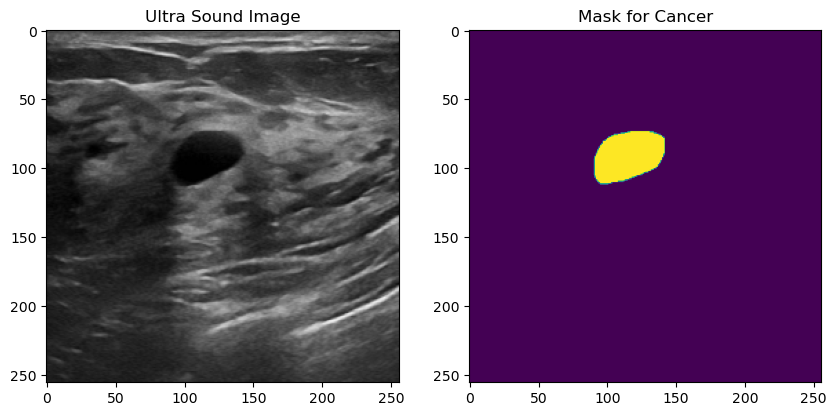

In [9]:
# displaying data loaded by our function
plt.figure(figsize = (10, 7))
plt.subplot(1,2,1)
plt.imshow(framObjTrain['img'][1])
plt.title('Ultra Sound Image')
plt.subplot(1,2,2)
plt.imshow(framObjTrain['mask'][1])
plt.title('Mask for Cancer')
plt.show()

## Model Defination

In [10]:
###########################################################################
#                                Model   Defination                       #
###########################################################################


# This block essentially performs 2 convolution
def Conv2dBlock(inputTensor, numFilters, kernelSize = 3, doBatchNorm = True):
    # First Conv
    x = tf.keras.layers.Conv2D(filters = numFilters, kernel_size = (kernelSize, kernelSize),
                              kernel_initializer = 'he_normal', padding = 'same') (inputTensor)
    
    if doBatchNorm:
        x = tf.keras.layers.BatchNormalization()(x)
        
    x =tf.keras.layers.Activation('relu')(x)
    
    # Second Conv
    x = tf.keras.layers.Conv2D(filters = numFilters, kernel_size = (kernelSize, kernelSize),
                              kernel_initializer = 'he_normal', padding = 'same') (x)
    if doBatchNorm:
        x = tf.keras.layers.BatchNormalization()(x)
        
    x = tf.keras.layers.Activation('relu')(x)
    
    return x


# Now defining Unet 
def GiveMeUnet(inputImage, numFilters = 16, droupouts = 0.1, doBatchNorm = True):
    # Defining encoder Path
    c1 = Conv2dBlock(inputImage, numFilters * 1, kernelSize = 3, doBatchNorm = doBatchNorm)
    p1 = tf.keras.layers.MaxPooling2D((2,2))(c1)
    p1 = tf.keras.layers.Dropout(droupouts)(p1)
    
    c2 = Conv2dBlock(p1, numFilters * 2, kernelSize = 3, doBatchNorm = doBatchNorm)
    p2 = tf.keras.layers.MaxPooling2D((2,2))(c2)
    p2 = tf.keras.layers.Dropout(droupouts)(p2)
    
    c3 = Conv2dBlock(p2, numFilters * 4, kernelSize = 3, doBatchNorm = doBatchNorm)
    p3 = tf.keras.layers.MaxPooling2D((2,2))(c3)
    p3 = tf.keras.layers.Dropout(droupouts)(p3)
    
    c4 = Conv2dBlock(p3, numFilters * 8, kernelSize = 3, doBatchNorm = doBatchNorm)
    p4 = tf.keras.layers.MaxPooling2D((2,2))(c4)
    p4 = tf.keras.layers.Dropout(droupouts)(p4)
    
    c5 = Conv2dBlock(p4, numFilters * 16, kernelSize = 3, doBatchNorm = doBatchNorm)
    
    # Defining decoder path
    u6 = tf.keras.layers.Conv2DTranspose(numFilters*8, (3, 3), strides = (2, 2), padding = 'same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    u6 = tf.keras.layers.Dropout(droupouts)(u6)
    c6 = Conv2dBlock(u6, numFilters * 8, kernelSize = 3, doBatchNorm = doBatchNorm)
    
    u7 = tf.keras.layers.Conv2DTranspose(numFilters*4, (3, 3), strides = (2, 2), padding = 'same')(c6)
    
    u7 = tf.keras.layers.concatenate([u7, c3])
    u7 = tf.keras.layers.Dropout(droupouts)(u7)
    c7 = Conv2dBlock(u7, numFilters * 4, kernelSize = 3, doBatchNorm = doBatchNorm)
    
    u8 = tf.keras.layers.Conv2DTranspose(numFilters*2, (3, 3), strides = (2, 2), padding = 'same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    u8 = tf.keras.layers.Dropout(droupouts)(u8)
    c8 = Conv2dBlock(u8, numFilters * 2, kernelSize = 3, doBatchNorm = doBatchNorm)
    
    u9 = tf.keras.layers.Conv2DTranspose(numFilters*1, (3, 3), strides = (2, 2), padding = 'same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    u9 = tf.keras.layers.Dropout(droupouts)(u9)
    c9 = Conv2dBlock(u9, numFilters * 1, kernelSize = 3, doBatchNorm = doBatchNorm)
    
    output = tf.keras.layers.Conv2D(1, (1, 1), activation = 'sigmoid')(c9)
    model = tf.keras.Model(inputs = [inputImage], outputs = [output])
    return model

In [11]:
# Convert data to numpy arrays
X = np.array(framObjTrain['img'])
y = np.array(framObjTrain['mask'])

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

inputs = tf.keras.layers.Input((256, 256, 3))
myTransformer = GiveMeUnet(inputs, droupouts=0.07)
myTransformer.compile(
    optimizer='Adam',
    loss=bce_dice_loss,
    metrics=[dice_coef, iou_coef, 'accuracy']
)

In [12]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model_iou.h5',  # Save best model based on IoU with a different filename
        monitor='val_iou_coef',
        save_best_only=True,
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_iou_coef',  # Use IoU as early stopping metric
        patience=20,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_iou_coef',  # Adjust learning rate based on IoU
        factor=0.5,
        patience=3,
        mode='max'
    )
]

Epoch 1/50


33/33 [==============================] - ETA: 0s - loss: 0.6946 - dice_coef: 0.1744 - iou_coef: 0.0870 - accuracy: 0.7660

e:\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


33/33 [==============================] - 38s 1s/step - loss: 0.6946 - dice_coef: 0.1744 - iou_coef: 0.0870 - accuracy: 0.7660 - val_loss: 7.3060 - val_dice_coef: 0.1681 - val_iou_coef: 0.0921 - val_accuracy: 0.0908 - lr: 0.0010
Epoch 2/50
33/33 [==============================] - 36s 1s/step - loss: 0.6102 - dice_coef: 0.1783 - iou_coef: 0.0859 - accuracy: 0.9050 - val_loss: 2.3525 - val_dice_coef: 0.1802 - val_iou_coef: 0.0987 - val_accuracy: 0.6191 - lr: 0.0010
Epoch 3/50
33/33 [==============================] - 38s 1s/step - loss: 0.5725 - dice_coef: 0.2065 - iou_coef: 0.1000 - accuracy: 0.9098 - val_loss: 3.3308 - val_dice_coef: 0.1903 - val_iou_coef: 0.1095 - val_accuracy: 0.4790 - lr: 0.0010
Epoch 4/50
33/33 [==============================] - 38s 1s/step - loss: 0.5353 - dice_coef: 0.2499 - iou_coef: 0.1227 - accuracy: 0.9005 - val_loss: 1.2191 - val_dice_coef: 0.2218 - val_iou_coef: 0.1266 - val_accuracy: 0.4692 - lr: 0.0010
Epoch 5/50
33/33 [==============================] - 37s

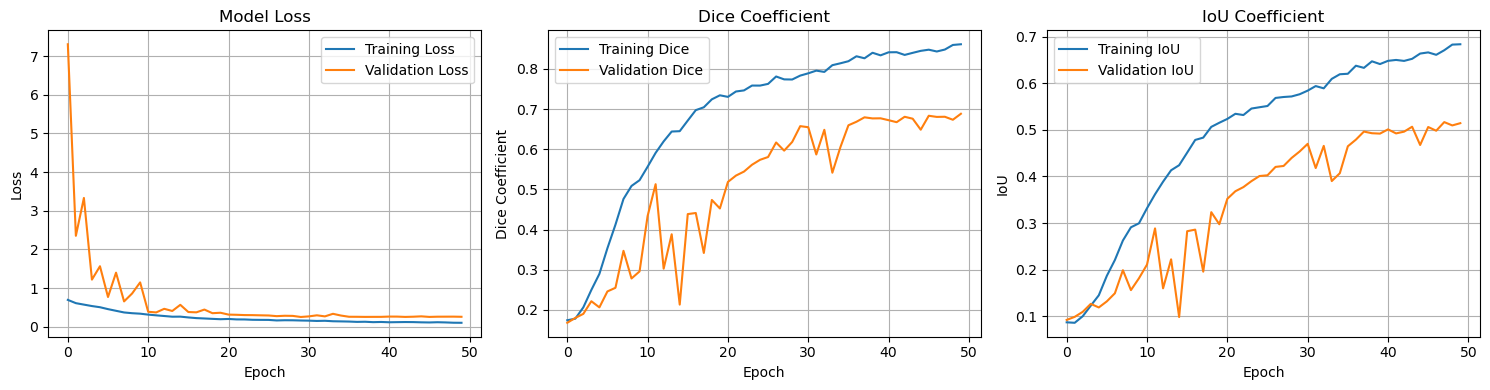

In [13]:
history = myTransformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,         # Train for 50 epochs
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

plot_training_history(history)

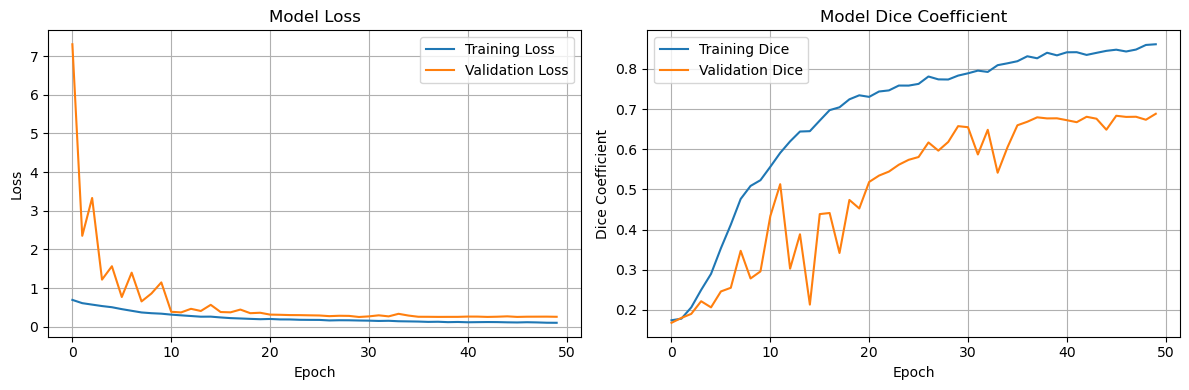

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')
plt.title('Model Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Testing

1/1 [==============================] - 0s 44ms/step


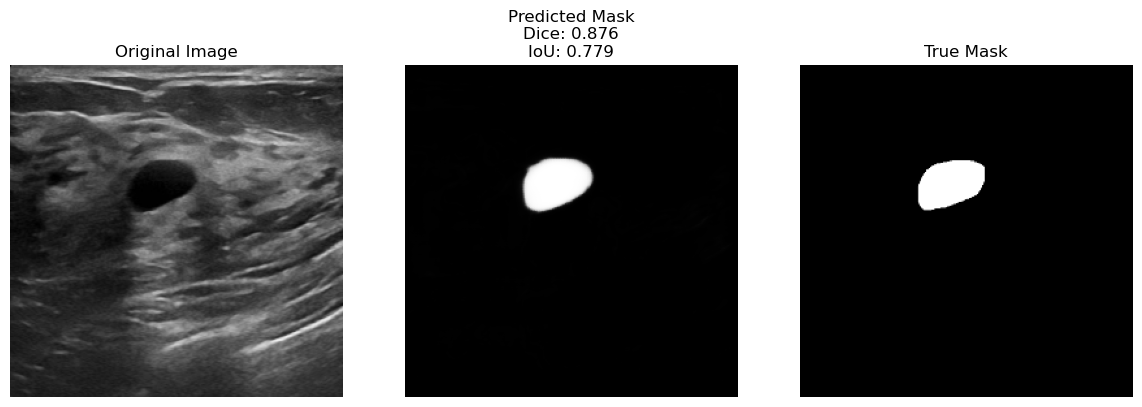

1/1 [==============================] - 0s 34ms/step


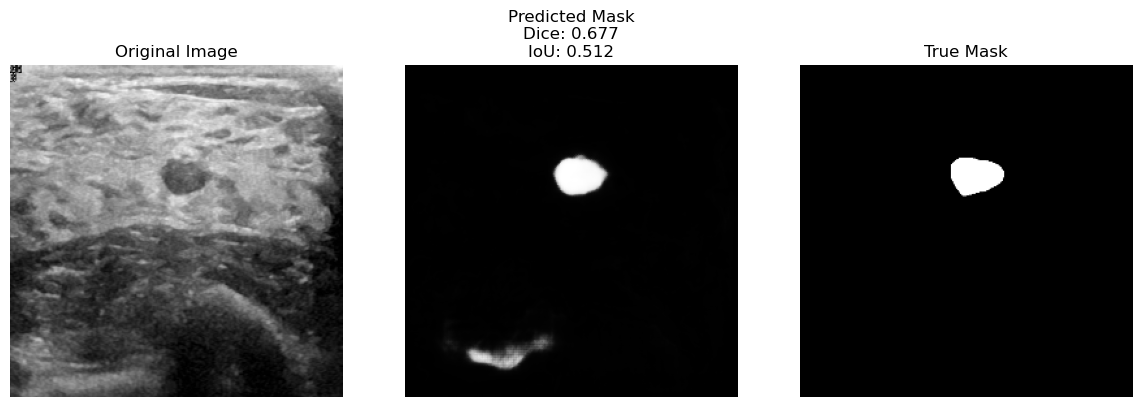

1/1 [==============================] - 0s 35ms/step


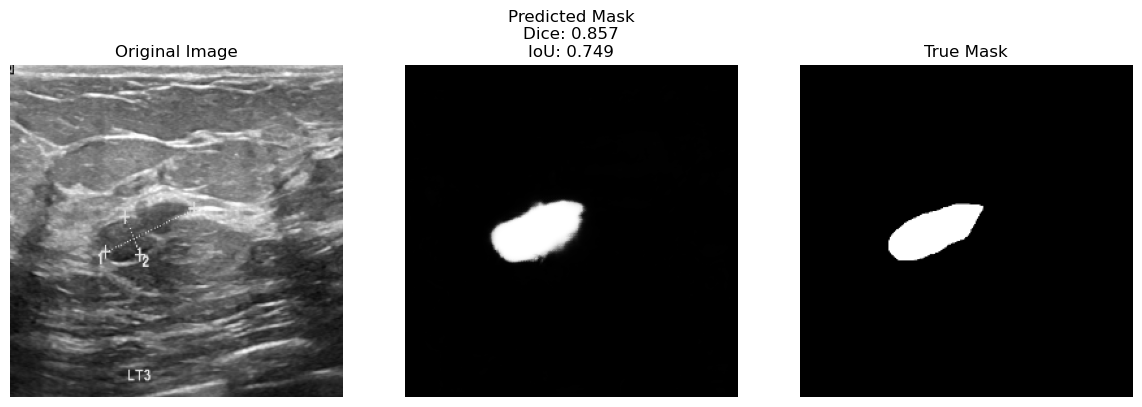

In [15]:
def predict16(valMap, model, shape=256):
    """
    Predict results for 16 samples
    """
    img = valMap['img'][0:16]
    mask = valMap['mask'][0:16]
    imgProc = np.array(img)
    predictions = model.predict(imgProc)
    return predictions, imgProc, mask

# Test code
sixteenPrediction, actuals, masks = predict16(framObjTrain, myTransformer)

# Display several prediction results
predict_and_plot(myTransformer, actuals[1], masks[1])
predict_and_plot(myTransformer, actuals[2], masks[2])
predict_and_plot(myTransformer, actuals[3], masks[3])

## Saving Model

In [16]:
myTransformer.save('BreastCancerSegmentor.h5')